In [1]:
import pandas as pd

file_path = "../data/processed/cleaned_data.csv"
df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (100000, 24)


In [2]:
product_data = df.groupby(["Brand", "Category"]).agg({
    "Units": "sum",
    "Revenue": "sum",
    "Selling_Price": "mean",
    "Margin": "mean",
    "Stock_On_Hand": "mean",
    "Reorder_Level": "mean",
    "Lead_Time_Days": "mean"
}).reset_index()

print("Product-level data created successfully!")
print("Shape:", product_data.shape)
print(product_data.head())

Product-level data created successfully!
Shape: (64, 9)
  Brand   Category  Units        Revenue  Selling_Price     Margin  \
0  Amul  Beverages   4879  632424.072252     129.945207  79.081237   
1  Amul      Dairy   4669  604374.379712     129.662792  77.365918   
2  Amul     Fruits   4430  590154.660891     133.525304  79.560168   
3  Amul    Grocery   4853  636096.635273     132.409866  80.882912   
4  Amul  Home Care   4886  637393.689531     130.632316  79.605605   

   Stock_On_Hand  Reorder_Level  Lead_Time_Days  
0     269.670412      49.424469        8.549313  
1     278.107097      49.050323        8.600000  
2     277.274074      49.123232        8.498316  
3     273.450031      49.497207        8.660459  
4     279.519290      49.195958        8.469688  


In [3]:
clustering_features = [
    "Units",
    "Revenue",
    "Selling_Price",
    "Margin",
    "Stock_On_Hand",
    "Reorder_Level",
    "Lead_Time_Days"
]

X_cluster = product_data[clustering_features]

print("Clustering features selected:")
print(clustering_features)

print("\nShape:", X_cluster.shape)

Clustering features selected:
['Units', 'Revenue', 'Selling_Price', 'Margin', 'Stock_On_Hand', 'Reorder_Level', 'Lead_Time_Days']

Shape: (64, 7)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Features standardized successfully!")
print("Shape:", X_scaled.shape)

Features standardized successfully!
Shape: (64, 7)


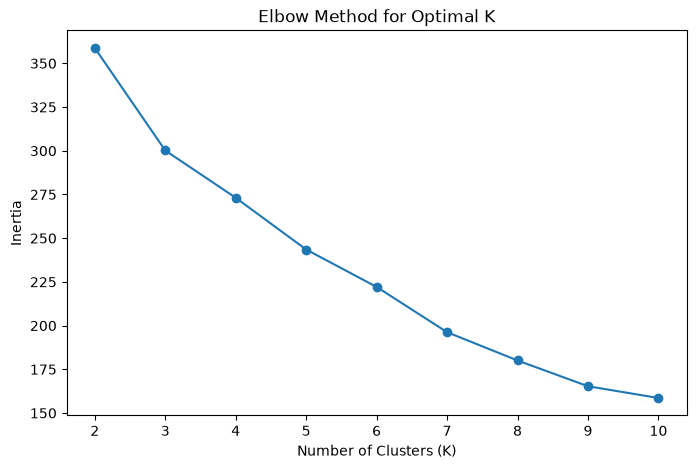

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k} : Silhouette Score = {score:.4f}")

K = 2 : Silhouette Score = 0.1725
K = 3 : Silhouette Score = 0.1732
K = 4 : Silhouette Score = 0.1539
K = 5 : Silhouette Score = 0.1594
K = 6 : Silhouette Score = 0.1715
K = 7 : Silhouette Score = 0.1810
K = 8 : Silhouette Score = 0.1819
K = 9 : Silhouette Score = 0.1898
K = 10 : Silhouette Score = 0.1734


In [7]:
kmeans = KMeans(
    n_clusters=9,
    random_state=42,
    n_init=10
)

product_data["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCluster sizes:")
print(product_data["KMeans_Cluster"].value_counts().sort_index())

K-Means clustering completed!

Cluster sizes:
KMeans_Cluster
0     9
1    10
2     7
3     7
4     8
5     5
6     7
7     3
8     8
Name: count, dtype: int64


In [8]:
print(
    product_data[
        ["Brand", "Category", "KMeans_Cluster"]
    ].sort_values("KMeans_Cluster").to_string(index=False)
)

    Brand      Category  KMeans_Cluster
     Amul         Dairy               0
Britannia         Dairy               0
Britannia       Grocery               0
      HUL Personal Care               0
  PepsiCo     Beverages               0
    Parle    Vegetables               0
    Parle        Fruits               0
   Nestle        Fruits               0
     Tata     Beverages               0
   Nestle     Home Care               1
  PepsiCo       Grocery               1
    Parle     Beverages               1
      ITC        Fruits               1
Britannia     Home Care               1
     Tata     Home Care               1
  PepsiCo     Home Care               1
  PepsiCo    Vegetables               1
     Tata Personal Care               1
  PepsiCo        Fruits               1
    Parle     Home Care               2
     Tata    Vegetables               2
    Parle        Snacks               2
      HUL         Dairy               2
      ITC         Dairy               2


In [9]:
cluster_profile = product_data.groupby("KMeans_Cluster")[clustering_features].mean()

print("Cluster profiles:")
print(cluster_profile.round(2))

Cluster profiles:
                  Units    Revenue  Selling_Price  Margin  Stock_On_Hand  \
KMeans_Cluster                                                             
0               4728.11  613546.83         129.44   77.48         275.18   
1               4719.30  610924.76         129.44   76.84         272.18   
2               4500.86  584203.32         130.09   77.09         273.73   
3               4901.71  640723.29         130.91   79.76         272.06   
4               4520.12  601742.38         132.88   80.20         278.09   
5               4688.60  630375.23         133.80   81.02         274.58   
6               4799.29  628858.01         131.46   78.50         278.40   
7               4700.33  621855.80         131.88   79.79         270.33   
8               4620.62  612011.38         132.17   80.06         271.15   

                Reorder_Level  Lead_Time_Days  
KMeans_Cluster                                 
0                       49.10            8.60  
1

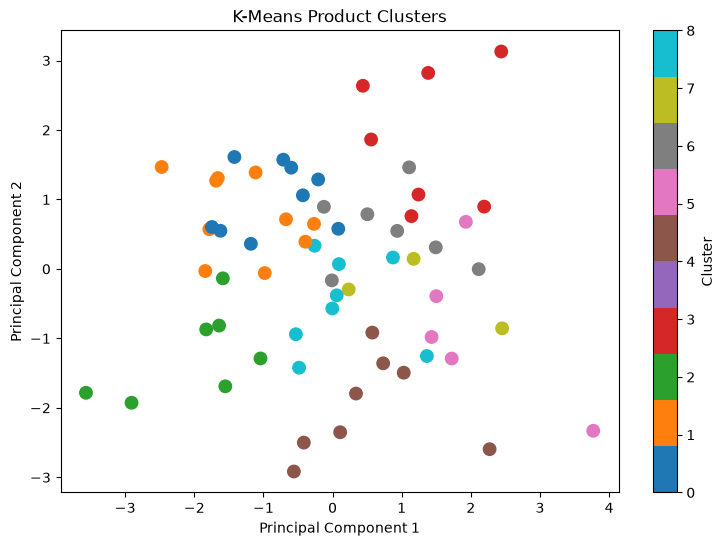

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=product_data["KMeans_Cluster"],
    cmap="tab10",
    s=80
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Product Clusters")

plt.colorbar(label="Cluster")
plt.show()

In [11]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=9,
    linkage="ward"
)

product_data["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)

print("Agglomerative Clustering completed!")

print("\nCluster sizes:")
print(
    product_data["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Agglomerative Clustering completed!

Cluster sizes:
Hierarchical_Cluster
0    10
1    12
2     8
3     3
4     9
5     7
6     3
7     8
8     4
Name: count, dtype: int64


In [12]:
hierarchical_score = silhouette_score(
    X_scaled,
    product_data["Hierarchical_Cluster"]
)

print("Agglomerative Clustering Silhouette Score:",
      round(hierarchical_score, 4))

Agglomerative Clustering Silhouette Score: 0.163


In [13]:
clustering_comparison = pd.DataFrame({
    "Model": ["K-Means", "Agglomerative Clustering"],
    "Silhouette Score": [0.1898, 0.1630]
})

print(clustering_comparison)

                      Model  Silhouette Score
0                   K-Means            0.1898
1  Agglomerative Clustering            0.1630


In [15]:
import joblib

joblib.dump(kmeans, "../models/clustering/kmeans.pkl")
joblib.dump(hierarchical, "../models/clustering/agglomerative.pkl")
joblib.dump(scaler, "../models/clustering/scaler.pkl")

print("Clustering models and scaler saved successfully!")

Clustering models and scaler saved successfully!
